In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds


In [3]:
dataset , dataset_info = tfds.load('malaria',with_info =True,as_supervised = True , shuffle_files =True , split=['train'])

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/malaria/incomplete.Q03RYC_1.0.0/malaria-train.tfrecord*...:   0%|         …

Dataset malaria downloaded and prepared to /root/tensorflow_datasets/malaria/1.0.0. Subsequent calls will reuse this data.


In [4]:
dataset_info

tfds.core.DatasetInfo(
    name='malaria',
    full_name='malaria/1.0.0',
    description="""
    The Malaria dataset contains a total of 27,558 cell images with equal instances
    of parasitized and uninfected cells from the thin blood smear slide images of
    segmented cells.
    """,
    homepage='https://lhncbc.nlm.nih.gov/publication/pub9932',
    data_dir='/root/tensorflow_datasets/malaria/1.0.0',
    file_format=tfrecord,
    download_size=337.08 MiB,
    dataset_size=317.62 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=27558, num_shards=4>,
    },
    citation="""@article{rajaraman2018pre,
      title={Pre-trained convolutional neural networks as feature extractors toward
      improved malaria parasit

In [63]:
dataset.type

AttributeError: 'list' object has no attribute 'type'

In [5]:
for data in dataset[0].take(4):
  print(data)

(<tf.Tensor: shape=(145, 148, 3), dtype=uint8, numpy=
array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)>, <tf.Tensor: shape=(), dtype=int64, numpy=1>)
(<tf.Tensor: shape=(133, 127, 3), dtype=uint8, numpy=
array([[[0, 0, 0],
        [0, 0, 0],
       

In [6]:
def splits(dataset ,TRAIN_RATIO, TEST_RATIO,VAL_RATIO):
  size = len(dataset)

  train_dataset = dataset.take(int(TRAIN_RATIO*size))

  val_test_dataset= dataset.skip(int(TRAIN_RATIO*size))
  val_dataset = val_test_dataset.take(int(VAL_RATIO*size))

  test_dataset = val_test_dataset.skip(int(VAL_RATIO*size))
  return train_dataset , val_dataset , test_dataset

In [7]:
TRAIN_RATIO =0.8
TEST_RATIO =0.1
VAL_RATIO =0.1

In [8]:
train_dataset , val_dataset, test_dataset = splits(dataset[0],TRAIN_RATIO,TEST_RATIO,VAL_RATIO)

In [9]:
print(list(train_dataset.take(1).as_numpy_iterator()),
 list(val_dataset.take(1).as_numpy_iterator()),
list(test_dataset.take(1).as_numpy_iterator()))

[(array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8), np.int64(1))] [(array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0,

In [10]:
for x, y in val_dataset.take(1):
    print(x.shape)

(133, 136, 3)


TypeError: Invalid shape (32, 224, 224, 3) for image data

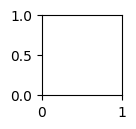

In [44]:
for i,(image,label) in enumerate(train_dataset.take(1)):
  ax=plt.subplot(4,4,i+1)
  plt.imshow(image)
  plt.title(dataset_info.features['label'].int2str(label))


In [12]:
#data processing
#need to make all the images resized and simillar make same pixel sizex
#standardization process
#we will go with normalization here

In [13]:
IM_SIZE =224
def resizing_rescale(image, label):
  return tf.image.resize(image,(IM_SIZE,IM_SIZE))/255,label

In [14]:
train_dataset =train_dataset.map(resizing_rescale)

In [15]:
val_dataset = val_dataset.map(resizing_rescale)


In [17]:
test_dataset = test_dataset.map(resizing_rescale)

In [18]:
for image,label in test_dataset.take(1):
  print(image,label)

tf.Tensor(
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]], shape=(224, 224, 3), dtype=float32) tf.Tensor(1, shape=(), dtype=int64)


In [20]:
train_dataset = train_dataset.shuffle(buffer_size=8,
                                     reshuffle_each_iteration=True).batch(32).prefetch(tf.data.AUTOTUNE)

In [21]:
val_dataset = val_dataset.shuffle(buffer_size=8,
                                     reshuffle_each_iteration=True).batch(32).prefetch(tf.data.AUTOTUNE)

In [22]:
test_dataset = test_dataset.shuffle(buffer_size=8,
                                     reshuffle_each_iteration=True).batch(32).prefetch(tf.data.AUTOTUNE)

In [43]:
from tensorflow.keras.layers import Conv2D, MaxPool2D,Dense,Flatten,InputLayer,BatchNormalization

model = tf.keras.Sequential([
    InputLayer(input_shape=(IM_SIZE,IM_SIZE,3)),

    tf.keras.layers.Conv2D(filters=6,kernel_size=5, strides=(1,1) , padding='valid',activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=2,strides=2),

    tf.keras.layers.Conv2D(filters=16,kernel_size=5,strides=(1,1),padding='valid',activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=2,strides=2),

    Flatten(),

    NeuralearnDense(1000,activation='relu'),
    BatchNormalization(),
    NeuralearnDense(100,activation='relu'),
    BatchNormalization(),
    NeuralearnDense(1,activation='sigmoid'),

])

model.summary()









Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 220, 220, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 220, 220, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 110, 110, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 106, 106, 16)   │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 106, 106, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 53, 53, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 44944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ neuralearn_dense_3              │ (None, 1000)           │    44,945,000 │
│ (NeuralearnDense)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 1000)           │         4,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ neuralearn_dense_4              │ (None, 100)            │       100,100 │
│ (NeuralearnDense)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ neuralearn_dense_5              │ (None, 1)              │           101 │
│ (NeuralearnDense)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,052,561 (171.86 MB)

 Trainable params: 45,050,317 (171.85 MB)

 Non-trainable params: 2,244 (8.77 KB)

Functional API

In [24]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D, MaxPool2D,Dense,Flatten,InputLayer,BatchNormalization

In [25]:
func_input = Input(shape=(IM_SIZE,IM_SIZE,3))
x = Conv2D(filters=6,kernel_size=5, strides=(1,1) , padding='valid',activation='relu')(func_input)
x = BatchNormalization()(x)
x = MaxPool2D(pool_size=2,strides=2)(x)

x=    tf.keras.layers.Conv2D(filters=16,kernel_size=5,strides=(1,1),padding='valid',activation='relu')(x)
x = BatchNormalization()(x)
output = MaxPool2D(pool_size=2,strides=2)(x)

freature_extractor = Model(inputs=func_input,outputs=output)
freature_extractor.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 220, 220, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 220, 220, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 110, 110, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 16)   │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 106, 106, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 53, 53, 16)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,960 (11.56 KB)

 Trainable params: 2,916 (11.39 KB)

 Non-trainable params: 44 (176.00 B)

In [30]:
func_input = Input(shape=(IM_SIZE,IM_SIZE,3))

x = feature_sub_classed(func_input)

x = Flatten()(x)

x = Dense(1000,activation='relu')(x)
x = BatchNormalization()(x)

x = Dense(100,activation='relu')(x)
x = BatchNormalization()(x)

func_output = Dense(1,activation='sigmoid')(x)

model = Model(inputs=func_input,outputs=func_output)
model.summary()




Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_extractor               │ (None, 54, 54, 8)      │           872 │
│ (FeatureExtractor)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 23328)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1000)           │    23,329,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1000)           │         4,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │       100,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,434,473 (89.40 MB)

 Trainable params: 23,432,241 (89.39 MB)

 Non-trainable params: 2,232 (8.72 KB)

Model subclassing

In [28]:
from tensorflow.keras.layers import Layer

In [29]:

class FeatureExtractor(Layer):
  def __init__(self,filters, kernel,strides,padding,activation,pool):
    super().__init__()

    self.conv1 = Conv2D(filters=filters,kernel_size=kernel, strides=strides , padding=padding,activation=activation)
    self.batch1 = BatchNormalization()
    self.maxpool1 = MaxPool2D(pool_size=pool,strides=2*strides)


    self.conv2 = Conv2D(filters=filters,kernel_size=kernel, strides=strides , padding=padding,activation=activation)
    self.batch2 = BatchNormalization()
    self.maxpool2 = MaxPool2D(pool_size=pool,strides=2*strides)

  def call(self,x):
    x=self.conv1(x)
    x=self.batch1(x)
    x=self.maxpool1(x)

    x=self.conv2(x)
    x=self.batch2(x)
    x=self.maxpool2(x)

    return x

feature_sub_classed = FeatureExtractor(8, 3,1,"valid","relu",2)

In [42]:
class NeuralearnDense(Layer):
  def __init__(self,output_units,activation):
    super().__init__()
    self.output_units = output_units
    self.activation =activation

  def build(self,input_features_shape):
    self.weight = self.add_weight(shape=(input_features_shape[-1],self.output_units),initializer ="random_normal",trainable =True)
    self.bias = self.add_weight(shape=(self.output_units,),initializer="random_normal",trainable =True)

  def call(self,input_features):
    if (self.activation == "relu"):
      return tf.nn.relu(tf.matmul(input_features, self.weight)+self.bias)
    elif (self.activation == "sigmoid"):
      return tf.nn.sigmoid(tf.matmul(input_features, self.weight)+self.bias)
    else:
      return tf.matmul(input_features, self.weight)+self.bias




In [52]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss = tf.keras.losses.BinaryCrossentropy(),
    metrics =metrics

)

In [53]:
history = model.fit(train_dataset,validation_data=val_dataset,epochs=4,verbose=1)

Epoch 1/4
689/689 ━━━━━━━━━━━━━━━━━━━━ 59s 74ms/step - accuracy: 0.8380 - auc: 0.9180 - fn: 1789.0000 - fp: 1782.0000 - loss: 0.3640 - precision: 0.8383 - recall: 0.8377 - tn: 9239.0000 - tp: 9236.0000 - val_accuracy: 0.8425 - val_auc: 0.9578 - val_fn: 32.0000 - val_fp: 402.0000 - val_loss: 0.4008 - val_precision: 0.7719 - val_recall: 0.9770 - val_tn: 961.0000 - val_tp: 1360.0000
Epoch 2/4
689/689 ━━━━━━━━━━━━━━━━━━━━ 44s 64ms/step - accuracy: 0.9331 - auc: 0.9751 - fn: 613.0000 - fp: 861.0000 - loss: 0.1910 - precision: 0.9236 - recall: 0.9444 - tn: 10159.0000 - tp: 10413.0000 - val_accuracy: 0.9510 - val_auc: 0.9799 - val_fn: 55.0000 - val_fp: 80.0000 - val_loss: 0.1758 - val_precision: 0.9437 - val_recall: 0.9606 - val_tn: 1279.0000 - val_tp: 1341.0000
Epoch 3/4
689/689 ━━━━━━━━━━━━━━━━━━━━ 50s 72ms/step - accuracy: 0.9444 - auc: 0.9825 - fn: 497.0000 - fp: 728.0000 - loss: 0.1586 - precision: 0.9353 - recall: 0.9549 - tn: 10293.0000 - tp: 10528.0000 - val_accuracy: 0.9445 - val_auc

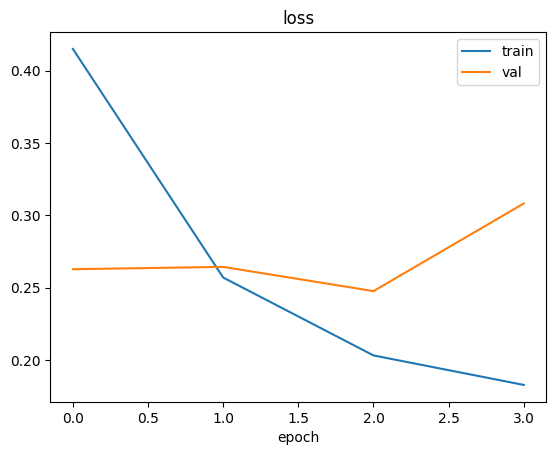

In [34]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss')
plt.xlabel('epoch')
plt.legend(['train','val'])
plt.show()

In [35]:
model.evaluate(test_dataset)

87/87 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.8919 - loss: 0.3435


[0.3435109555721283, 0.891911506652832]

In [36]:
model.predict(test_dataset.take(1))[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


np.float32(0.19213092)

In [37]:
def parasite_or_not(x):
  if x>0.5:
    return "p"
  else:
    return "U"

In [38]:
parasite_or_not(model.predict(test_dataset.take(1))[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


'U'

Evaluation of the model

In [47]:
from tensorflow.keras.metrics import Precision,Recall,BinaryAccuracy,FalseNegatives,FalsePositives,TrueNegatives,TruePositives,AUC

In [51]:
metrics = [TrueNegatives(name='tn'),TruePositives(name='tp'),FalseNegatives(name='fn'),FalsePositives(name='fp'),BinaryAccuracy(name='accuracy'),Precision(name='precision'),Recall(name='recall'),AUC(name='auc') ]

In [54]:
import sklearn

In [55]:
from sklearn.metrics import confusion_matrix

In [56]:
import seaborn as sns


In [57]:
#visualizing the confusion matrix


In [60]:
labels =[]
for x,y in test_dataset.as_numpy_iterator():
  labels.append(y)

In [64]:
labels = np.array([i[0] for i in labels])

In [65]:
labels

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0])